# Examples required for how to call the preprocessors

In [2]:
import sys
sys.path.append("../")
from dcmppln.utils.preprocess_ticker_data import calculate_returns_correlations
from tests.input_data import InputData
from typing import List
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt


## Load the example data

In [3]:

def download_data(stocks: List[str], start_date: str, end_date: str, period_step: int) -> pd.DataFrame:
    stock_data = {}
    for stock in stocks:
        ticker = yf.Ticker(stock)
        stock_data[stock] = ticker.history(start=start_date, end=end_date)["Close"][::period_step]
    return pd.DataFrame(stock_data)

# Define time period for analysis
start_date = "2010-07-01"
end_date = "2020-07-01"
period_step = 5  # Weekly changes
# Create a portfolio
big_portfolio = ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'TSLA', 'QQQ', 'VGT',
                    'IGM', 'UNH', 'JNJ', 'PFE', 'MRK', 'LLY', 'BMY', 'TMO', 'ISRG', 'XLV', 'PG',
                    'KO', 'PEP', 'WMT', 'COST', 'CL', 'MDLZ', 'TGT', 'SYY', 'NVDA', 'AMD', 'INTC',
                    'TSM', 'QCOM', 'AVGO', 'ASML', 'TXN', 'MU', 'LRCX', 'JPM', 'BAC', 'GS', 'WFC',
                    'C', 'MS', 'SCHW', 'V', 'MA', 'XLF', 'WMT', 'TGT', 'COST', 'HD', 'LOW', 'ULTA',
                    'NKE', 'SBUX', 'AMZN', 'XRT', 'CAT', 'GE', 'HON', 'DE', 'LMT', 'BA', 'MMM',
                    'RTX', 'EMR', 'XLI']
dataset = download_data(big_portfolio, start_date, end_date, period_step)
# Compute summary stats for PO
po_data = calculate_returns_correlations(dataset, True)

In [5]:
# Utility Script to visualize the matrices
def plot_results(C_Noise, C_Star, C_Global):
    f, ax = plt.subplots(1, 3, figsize=(15,5))
    # Plot data on each subplot
    ax[0].imshow(C_Noise, cmap='viridis')
    ax[0].set_title("C_Noise")
    ax[0].colorbar = plt.colorbar(ax[0].imshow(C_Noise, cmap='viridis'), ax=ax[0])

    ax[1].imshow(C_Star, cmap='viridis')
    ax[1].set_title("C_Star")
    ax[1].colorbar = plt.colorbar(ax[1].imshow(C_Star, cmap='viridis'), ax=ax[1])

    ax[2].imshow(C_Global, cmap='viridis')
    ax[2].set_title("C_Global")
    ax[2].colorbar = plt.colorbar(ax[2].imshow(C_Global, cmap='viridis'), ax=ax[2])

    # Adjust layout
    plt.tight_layout()

In [6]:
########################################### Unpack summary stats#########################################################
# These are the 4 basic variables we should use below
raw_returns = po_data.returns    # Returns for each stock as a function of time
returns = po_data.mean_returns   # Log mean returns for each stock
covariances = po_data.covariances # Covariances of the log mean returns
correlations = po_data.correlations # Correlations of the log mean returns

Example 1: Shrinkage (Done)

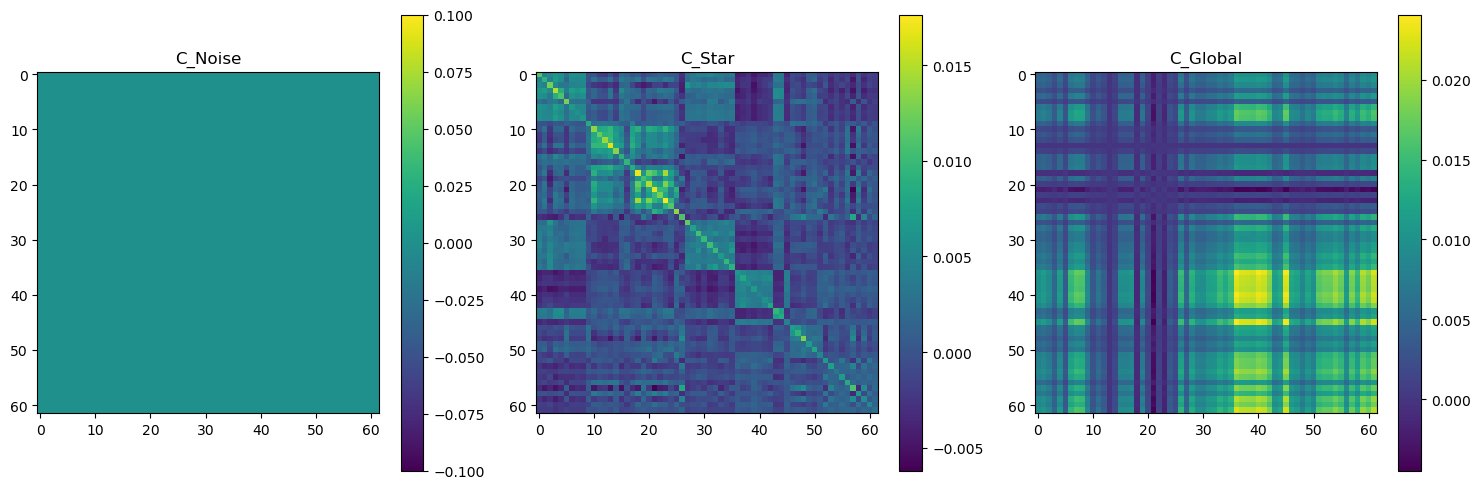

In [7]:
from dcmppln.utils import correlation_ledoit_wolf

C_Noise, C_Star, C_Global = correlation_ledoit_wolf.split_covariance_matrices(correlations, gamma=0.1)
plot_results(C_Noise, C_Star, C_Global)

Example 2: Bayesian PCA

In [11]:
#from dcmppln.utils import correlation_bayesian_PCA

#C_Noise, C_Star, C_Global = correlation_bayesian_PCA.split_covariance_matrices(C=, data=, n_components=None)
#plot_results(C_Noise, C_Star, C_Global)

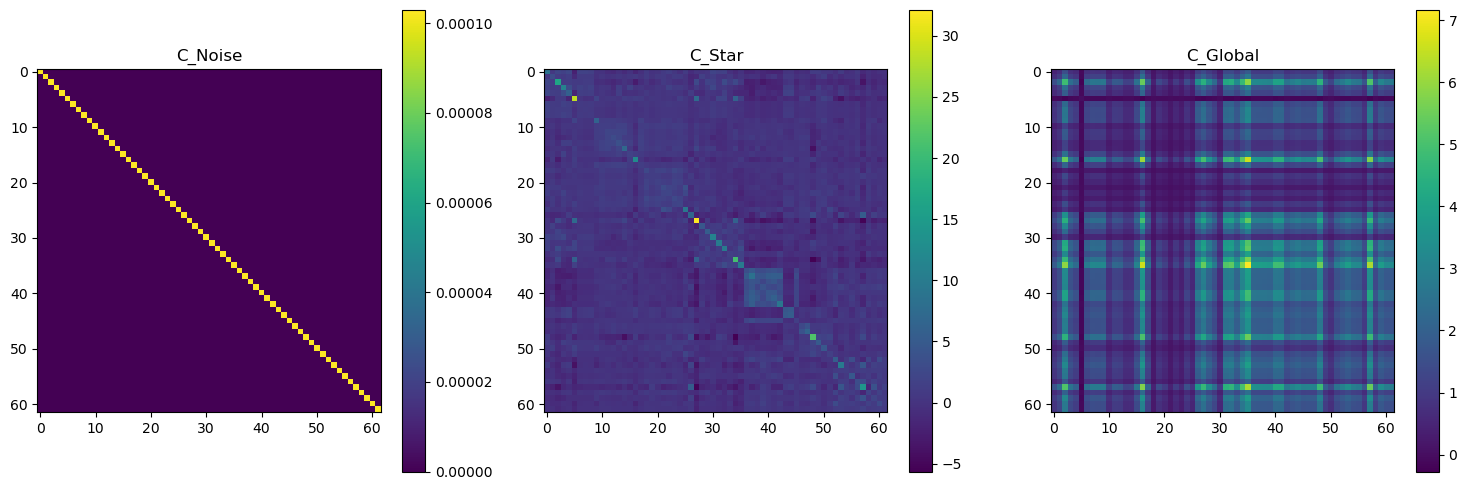

In [9]:
from dcmppln.utils import correlation_bayesian_PCA

C_Noise, C_Star, C_Global = correlation_bayesian_PCA.split_covariance_matrices(C=correlations, data=raw_returns, n_components=None)
plot_results(C_Noise, C_Star, C_Global)

Example 3: Bootstrap

In [ ]:
#from dcmppln.utils import correlation_bootstrap

#C_Noise, C_Star, C_Global = correlation_bootstrap.split_covariance_matrices(C_shrunk=, lambda_robust=)
#plot_results(C_Noise, C_Star, C_Global)

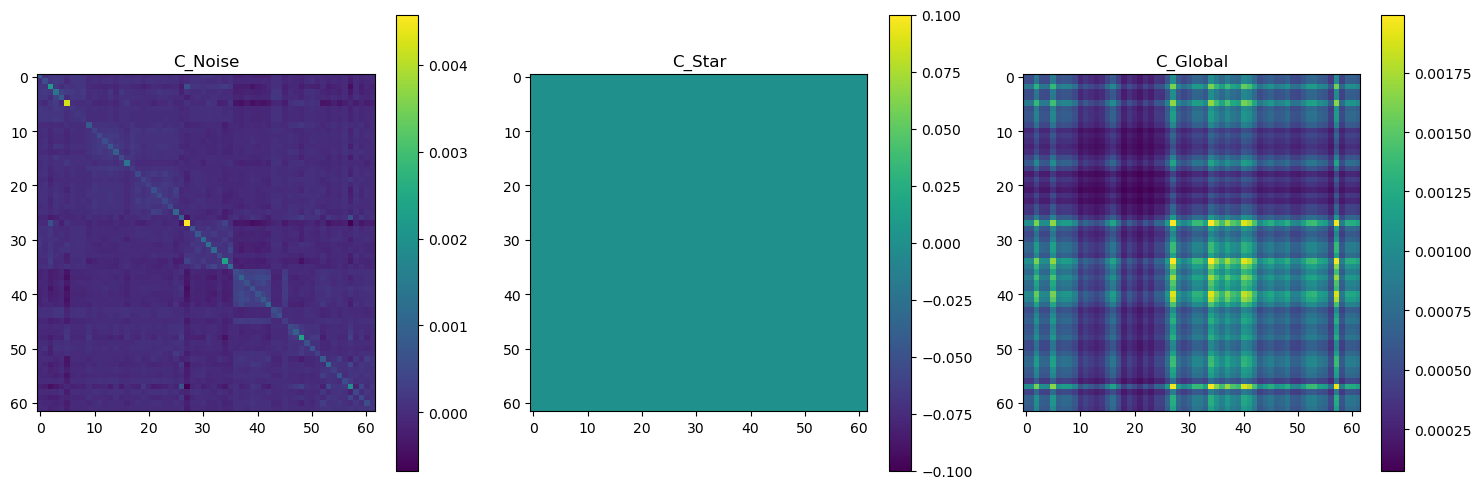

In [10]:
from dcmppln.utils import correlation_bootstrap
from sklearn.covariance import LedoitWolf

# Compute the shrunk covariance matrix from the data
C_shrunk = LedoitWolf().fit(raw_returns).covariance_

# Compute the dynamic noise threshold
lambda_robust = correlation_bootstrap.bootstrap_threshold(C_shrunk)

# Split the covariance matrix into components
C_Noise, C_Star, C_Global = correlation_bootstrap.split_covariance_matrices(C_shrunk=C_shrunk, lambda_robust=lambda_robust)

# Plot the results
plot_results(C_Noise, C_Star, C_Global)

Example 4: PTS

In [13]:
#from dcmppln.utils import correlation_pts

#C_Noise, C_Star, C_Global = correlation_pts.split_covariance_matrices(C_shrunk=, lambda_robust=)
#plot_results(C_Noise, C_Star, C_Global)

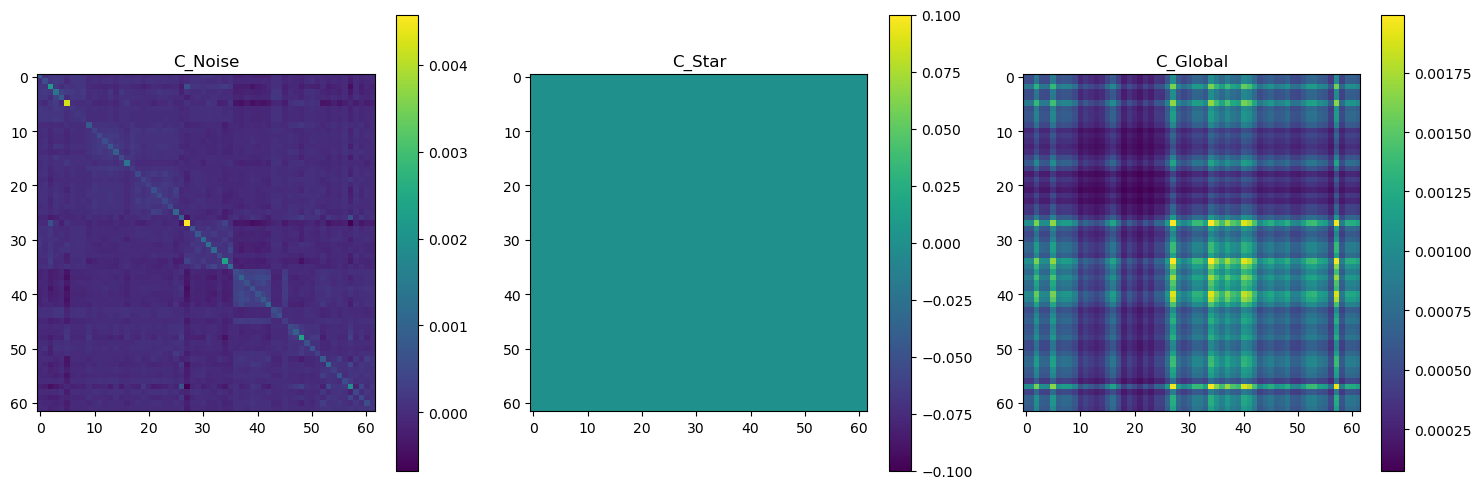

In [12]:
from dcmppln.utils import correlation_pts
from sklearn.covariance import LedoitWolf

# Compute the shrunk covariance matrix from the data
C_shrunk = LedoitWolf().fit(raw_returns).covariance_

# Compute the dynamic noise threshold
lambda_robust = correlation_pts.permutation_test_threshold(raw_returns)

# Split the covariance matrix into components
C_Noise, C_Star, C_Global = correlation_pts.split_covariance_matrices(C_shrunk=C_shrunk, lambda_robust=lambda_robust)

# Plot the results
plot_results(C_Noise, C_Star, C_Global)